In [1]:
# STEP 1: Install dependencies
!pip install roboflow ultralytics --quiet
!pip install supervision --quiet

import os
import shutil
import yaml
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 116.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 9.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from roboflow import Roboflow
from google.colab import userdata

# Store your key in Colab → Secrets (key icon in sidebar) as ROBOFLOW_API_KEY
API_KEY = userdata.get("ROBOFLOW_API_KEY")
rf = Roboflow(api_key=API_KEY)

DATASETS = [
    ("nicco-van-hamja-b1vxy", "braillify"),
    ("braille-lq5eh",         "braille-final-27-04"),
    ("braille-eitpg",         "braille-detection-f0rb5"),
    # ("braille-m3uyq",         "braille-genesis"),
    # ("braille-dpcya",         "braille-genesis1"),
    ("braille-to-text-0xo2p", "braille-to-text-custom-vtzmb"),
    ("braille-jjezl",         "braille-detection-v2-xpwue"),
]

download_paths = []

for workspace, project_name in DATASETS:
    print(f"\nDownloading: {project_name} ...")
    try:
        project = rf.workspace(workspace).project(project_name)

        # Auto-detect latest available version
        versions = project.versions()
        if not versions:
            print(f"    No versions found for {project_name}, skipping.")
            continue

        # Pick the latest version (highest version number)
        latest = max(versions, key=lambda v: v.version)
        print(f"  Using version: {latest.version}")

        dataset = latest.download(
            "yolov8",
            location=f"/content/datasets/{project_name}"
        )
        download_paths.append(f"/content/datasets/{project_name}")
        print(f"  ✓ Done: {project_name}")

    except Exception as e:
        print(f"   Failed: {project_name} — {e}")
        print(f"     Skipping and continuing...")
        continue

print(f"\n Successfully downloaded {len(download_paths)}/{len(DATASETS)} datasets")
print("Paths:", download_paths)


Downloading: braillify ...
loading Roboflow workspace...
loading Roboflow project...
  Using version: 1



Extracting Dataset Version Zip to /content/datasets/braillify in yolov8:: 100%|██████████| 7650/7650 [00:00<00:00, 9919.70it/s] 

  ✓ Done: braillify

Downloading: braille-final-27-04 ...
loading Roboflow workspace...


loading Roboflow project...
  Using version: 2



Extracting Dataset Version Zip to /content/datasets/braille-final-27-04 in yolov8:: 100%|██████████| 4140/4140 [00:00<00:00, 10883.30it/s]

...


Extracting Dataset Version Zip to /content/datasets/braille-to-text-custom-vtzmb in yolov8:: 100%|██████████| 736/736 [00:00<00:00, 5383.43it/s]

  ✓ Done: braille-to-text-custom-vtzmb

Downloading: braille-detection-v2-xpwue ...
loading Roboflow workspace...


loading Roboflow project...
  Using version: 1



Extracting Dataset Version Zip to /content/datasets/braille-detection-v2-xpwue in yolov8:: 100%|██████████| 2660/2660 [00:00<00:00, 10271.23it/s]

  ✓ Done: braille-detection-v2-xpwue

 Successfully downloaded 5/7 datasets
Paths: ['/content/datasets/braillify', '/content/datasets/braille-final-27-04', '/content/datasets/braille-detection-f0rb5', '/content/datasets/braille-to-text-custom-vtzmb', '/content/datasets/braille-detection-v2-xpwue']


In [3]:
import os
import glob

print("Dataset inventory:\n")
total = 0
for path in download_paths:
    name = path.split('/')[-1]
    imgs = 0
    for split in ['train', 'valid', 'test']:
        n = len(glob.glob(f"{path}/{split}/images/*"))
        imgs += n
    total += imgs
    print(f"  {name}: {imgs} images")

print(f"\n  Total images available: {total}")
print(f"  Number of datasets: {len(download_paths)}")

Dataset inventory:

  braillify: 3819 images
  braille-final-27-04: 2064 images
  braille-detection-f0rb5: 6013 images
  braille-to-text-custom-vtzmb: 362 images
  braille-detection-v2-xpwue: 1324 images

  Total images available: 13582
  Number of datasets: 5


In [ ]:
# # Cell 3 - Fixed Angelina converter based on actual file format
# # Format: x1;y1;x2;y2;label_int  (semicolon separated, normalized coords)

# import os
# import glob
# import shutil
# import cv2
# from pathlib import Path

# STANDARD_CLASSES = [chr(i) for i in range(ord('A'), ord('Z')+1)]

# # Angelina uses integer codes for Braille characters
# # Code = decimal value of 6-bit dot pattern (dots 1-6)
# BRAILLE_INT_TO_LETTER = {
#      1:'A',  3:'B',  9:'C', 25:'D', 17:'E',
#     11:'F', 27:'G', 19:'H',  5:'I',  7:'J',
#     33:'K', 35:'L', 41:'M', 57:'N', 49:'O',
#     43:'P', 59:'Q', 51:'R', 37:'S', 53:'T',
#     45:'U', 47:'V', 55:'W', 39:'X', 61:'Y', 63:'Z'
# }

# def convert_angelina_to_yolo(angelina_dir, output_dir):
#     os.makedirs(f"{output_dir}/images", exist_ok=True)
#     os.makedirs(f"{output_dir}/labels", exist_ok=True)

#     converted = 0
#     skipped   = 0
#     no_img    = 0

#     csv_files = glob.glob(f"{angelina_dir}/**/*.csv", recursive=True)
#     print(f"Processing {len(csv_files)} CSV files...")

#     for csv_file in csv_files:
#         # Find matching image (same name, different extension)
#         base = csv_file.replace('.labeled.csv', '')
#         img_file = None
#         for ext in ['.labeled.jpg', '.labeled.JPG', '.labeled.png',
#                     '.jpg', '.JPG', '.png']:
#             candidate = base + ext
#             if os.path.exists(candidate):
#                 img_file = candidate
#                 break

#         if img_file is None:
#             no_img += 1
#             continue

#         yolo_lines = []
#         with open(csv_file, 'r') as f:
#             for line in f.readlines():
#                 line = line.strip()
#                 if not line:
#                     continue
#                 parts = line.split(';')
#                 if len(parts) < 5:
#                     continue
#                 try:
#                     # Format: x1;y1;x2;y2;label_int
#                     x1    = float(parts[0])
#                     y1    = float(parts[1])
#                     x2    = float(parts[2])
#                     y2    = float(parts[3])
#                     label = int(parts[4])

#                     if label not in BRAILLE_INT_TO_LETTER:
#                         continue  # skip numbers, punctuation

#                     letter = BRAILLE_INT_TO_LETTER[label]
#                     cls_id = STANDARD_CLASSES.index(letter)

#                     # Coords are already normalized — just convert to YOLO format
#                     xc = (x1 + x2) / 2
#                     yc = (y1 + y2) / 2
#                     bw = x2 - x1
#                     bh = y2 - y1

#                     # Sanity check
#                     if 0 < xc < 1 and 0 < yc < 1 and bw > 0 and bh > 0:
#                         yolo_lines.append(
#                             f"{cls_id} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")
#                 except:
#                     continue

#         if yolo_lines:
#             stem = Path(img_file).stem
#             # Clean stem (remove .labeled suffix if present)
#             stem = stem.replace('.labeled', '')
#             dest_img = f"{output_dir}/images/{stem}.jpg"
#             dest_lbl = f"{output_dir}/labels/{stem}.txt"
#             shutil.copy(img_file, dest_img)
#             with open(dest_lbl, 'w') as f:
#                 f.write('\n'.join(yolo_lines))
#             converted += 1
#         else:
#             skipped += 1

#     print(f"\nAngelina conversion results:")
#     print(f"  Converted : {converted} images")
#     print(f"  Skipped   : {skipped} (no matching letters in our A-Z set)")
#     print(f"  No image  : {no_img} (CSV had no matching image file)")
#     return output_dir

# # Remove old failed output and reconvert
# !rm -rf /content/angelina_yolo

# angelina_out = convert_angelina_to_yolo(
#     "/content/AngelinaDataset  # upload this folder to Colab via Files panel or Drive",
#     "/content/angelina_yolo"
# )

# # Verify output
# imgs = glob.glob("/content/angelina_yolo/images/*")
# lbls = glob.glob("/content/angelina_yolo/labels/*")
# print(f"\nVerification:")
# print(f"  Images in output: {len(imgs)}")
# print(f"  Labels in output: {len(lbls)}")

# # Show a sample label to confirm format is correct
# if lbls:
#     print(f"\nSample label ({Path(lbls[0]).name}):")
#     with open(lbls[0], 'r') as f:
#         for line in f.readlines()[:3]:
#             print(f"  {line.strip()}")

Processing 0 CSV files...

Angelina conversion results:
  Converted : 0 images
  Skipped   : 0 (no matching letters in our A-Z set)
  No image  : 0 (CSV had no matching image file)

Verification:
  Images in output: 0
  Labels in output: 0


In [5]:
# STEP 4: Merge all datasets + proper stratified 70/15/15 split

import random
from collections import defaultdict

MERGED_DIR = "/content/merged_dataset"
for split in ["train", "valid", "test"]:
    os.makedirs(f"{MERGED_DIR}/images/{split}", exist_ok=True)
    os.makedirs(f"{MERGED_DIR}/labels/{split}", exist_ok=True)

STANDARD_CLASSES = [chr(i) for i in range(ord('A'), ord('Z')+1)]

#  PHASE 1: Collect ALL images from all datasets into a flat pool

all_samples = []  # list of (img_path, label_path, classes_present)

def load_yaml_classes(yaml_path):
    with open(yaml_path, 'r') as f:
        data = yaml.safe_load(f)
    return [str(c).upper() for c in data['names']]

def collect_samples(dataset_path):
    yaml_path = glob.glob(f"{dataset_path}/*.yaml")[0]
    source_classes = load_yaml_classes(yaml_path)

    remap = {}
    for src_idx, cls_name in enumerate(source_classes):
        if cls_name.upper() in STANDARD_CLASSES:
            remap[src_idx] = STANDARD_CLASSES.index(cls_name.upper())

    # Collect from ALL splits (we will re-split ourselves)
    for split in ["train", "valid", "test"]:
        img_dir = f"{dataset_path}/{split}/images"
        lbl_dir = f"{dataset_path}/{split}/labels"
        if not os.path.exists(img_dir):
            continue
        for img_file in glob.glob(f"{img_dir}/*"):
            stem = Path(img_file).stem
            lbl_file = f"{lbl_dir}/{stem}.txt"
            if not os.path.exists(lbl_file):
                continue
            # Remap labels
            new_lines = []
            classes_present = set()
            with open(lbl_file, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    src_cls = int(parts[0])
                    if src_cls in remap:
                        new_cls = remap[src_cls]
                        new_lines.append(f"{new_cls} {' '.join(parts[1:])}")
                        classes_present.add(new_cls)
            if new_lines:
                all_samples.append((img_file, new_lines, classes_present))

print("Collecting all samples...")
for path in download_paths:
    collect_samples(path)

print(f"Total samples collected: {len(all_samples)}")

# ── PHASE 2: Stratified split 70 / 15 / 15 ──────────────────────────────────
# Group samples by their primary class (most frequent class in image)
class_buckets = defaultdict(list)
for i, (img_path, lines, classes_present) in enumerate(all_samples):
    # Assign to bucket of the first class found (primary class)
    primary_class = sorted(classes_present)[0] if classes_present else 0
    class_buckets[primary_class].append(i)

train_indices, valid_indices, test_indices = [], [], []

random.seed(42)  # reproducibility

for cls_id, indices in class_buckets.items():
    random.shuffle(indices)
    n = len(indices)
    n_train = int(n * 0.70)
    n_valid = int(n * 0.15)
    # remaining go to test
    train_indices.extend(indices[:n_train])
    valid_indices.extend(indices[n_train:n_train + n_valid])
    test_indices.extend(indices[n_train + n_valid:])

print(f"\n Split Summary:")
print(f"  Train : {len(train_indices)} images ({len(train_indices)/len(all_samples)*100:.1f}%)")
print(f"  Valid : {len(valid_indices)} images ({len(valid_indices)/len(all_samples)*100:.1f}%)")
print(f"  Test  : {len(test_indices)} images  ({len(test_indices)/len(all_samples)*100:.1f}%)")

#  PHASE 3: Copy files into final merged structure
def write_split(indices, split_name):
    for counter, idx in enumerate(indices):
        img_path, new_lines, _ = all_samples[idx]
        ext = Path(img_path).suffix
        new_name = f"{split_name}_{counter:06d}"

        shutil.copy(img_path,
                    f"{MERGED_DIR}/images/{split_name}/{new_name}{ext}")

        with open(f"{MERGED_DIR}/labels/{split_name}/{new_name}.txt", 'w') as f:
            f.write('\n'.join(new_lines))

write_split(train_indices, "train")
write_split(valid_indices, "valid")
write_split(test_indices,  "test")

print("\n Merged dataset with proper 70/15/15 split is ready!")

#  PHASE 4: Verify class distribution
print("\n Class distribution in training set (first 5 classes):")
class_count = defaultdict(int)
for idx in train_indices:
    _, _, classes_present = all_samples[idx]
    for c in classes_present:
        class_count[c] += 1

for cls_id in sorted(class_count)[:5]:
    print(f"  {STANDARD_CLASSES[cls_id]}: {class_count[cls_id]} images")
print("  ...")

Total samples collected: 10822

 Split Summary:
  Train : 7564 images (69.9%)
  Valid : 1608 images (14.9%)
  Test  : 1650 images  (15.2%)

 Merged dataset with proper 70/15/15 split is ready!

 Class distribution in training set (first 5 classes):
  A: 4503 images
  B: 1899 images
  C: 2472 images
  D: 4193 images
  E: 6171 images
  ...


In [6]:
# STEP 5: Create the unified data.yaml and verify the dataset

data_yaml = {
    'path': MERGED_DIR,
    'train': 'images/train',
    'val':   'images/valid',
    'test':  'images/test',
    'nc': 26,
    'names': STANDARD_CLASSES
}

yaml_path = f"{MERGED_DIR}/data.yaml"
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print("data.yaml created:")
print(open(yaml_path).read())

# Count images per split
for split in ['train', 'valid', 'test']:
    n = len(glob.glob(f"{MERGED_DIR}/images/{split}/*"))
    print(f"  {split}: {n} images")

data.yaml created:
names:
- A
- B
- C
- D
- E
- F
- G
- H
- I
- J
- K
- L
- M
- N
- O
- P
- Q
- R
- S
- T
- U
- V
- W
- X
- Y
- Z
nc: 26
path: /content/merged_dataset
test: images/test
train: images/train
val: images/valid

  train: 7564 images
  valid: 1608 images
  test: 1650 images


In [7]:
# STEP 6: Train YOLOv8 nano (smallest = fastest on mobile)

model = YOLO("yolov8n.pt")  # nano — lightweight for TFLite export

results = model.train(
    data=yaml_path,
    epochs=50,           # increase to 100 if time allows
    imgsz=640,
    batch=16,
    name="braille_yolov8n",
    project="/content/runs",
    patience=10,         # early stopping
    augment=True,        # helps with real-world noise/lighting
    degrees=5,           # slight rotation augmentation
    hsv_v=0.4,          # brightness variation (simulates lighting)
    flipud=0.0,          # don't flip vertically (Braille is directional)
    fliplr=0.0,          # don't flip horizontally
    mosaic=1.0,
    cache=True,
    device=0             # GPU; use 'cpu' if no GPU available
)

print("Training complete!")

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/merged_dataset/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=braille_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

In [8]:
# Cell 7 - Save and verify best model

import os
import shutil
from pathlib import Path

# Path where YOLOv8 saved the best model automatically
best_model_path = "/content/runs/braille_yolov8n/weights/best.pt"
last_model_path = "/content/runs/braille_yolov8n/weights/last.pt"

# Create a dedicated output folder
save_dir = "/content/saved_models"
os.makedirs(save_dir, exist_ok=True)

# Copy both models to saved_models folder
shutil.copy(best_model_path, f"{save_dir}/braille_best.pt")
shutil.copy(last_model_path, f"{save_dir}/braille_last.pt")

# Verify they saved correctly
best_size = Path(f"{save_dir}/braille_best.pt").stat().st_size / (1024*1024)
last_size = Path(f"{save_dir}/braille_last.pt").stat().st_size / (1024*1024)

print("Models saved successfully!")
print(f"  braille_best.pt : {best_size:.1f} MB")
print(f"  braille_last.pt : {last_size:.1f} MB")
print(f"  Location        : {save_dir}")

# Load and confirm the model works
from ultralytics import YOLO
model = YOLO(f"{save_dir}/braille_best.pt")
print(f"\nModel loaded successfully!")
print(f"  Task    : {model.task}")
print(f"  Classes : {list(model.names.values())}")
print(f"  Num classes : {len(model.names)}")

Models saved successfully!
  braille_best.pt : 6.0 MB
  braille_last.pt : 6.0 MB
  Location        : /content/saved_models

Model loaded successfully!
  Task    : detect
  Classes : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
  Num classes : 26


In [9]:
import os
import shutil
from pathlib import Path
from ultralytics import YOLO

# Paths
best_model_path = "/content/runs/braille_yolov8n/weights/best.pt"
last_model_path = "/content/runs/braille_yolov8n/weights/last.pt"

# Create save folder
save_dir = "/content/saved_models"
os.makedirs(save_dir, exist_ok=True)

# Copy models
shutil.copy(best_model_path, f"{save_dir}/braille_best.pt")
shutil.copy(last_model_path, f"{save_dir}/braille_last.pt")

# Verify sizes
best_size = Path(f"{save_dir}/braille_best.pt").stat().st_size / (1024*1024)
last_size = Path(f"{save_dir}/braille_last.pt").stat().st_size / (1024*1024)

print("Models saved!")
print(f"  braille_best.pt : {best_size:.1f} MB")
print(f"  braille_last.pt : {last_size:.1f} MB")

# Confirm model loads correctly
model = YOLO(f"{save_dir}/braille_best.pt")
print(f"\nModel verified!")
print(f"  Classes : {list(model.names.values())}")

Models saved!
  braille_best.pt : 6.0 MB
  braille_last.pt : 6.0 MB

Model verified!
  Classes : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [10]:
import shutil
import pandas as pd

results_dir = "/content/runs/braille_yolov8n"
save_dir    = "/content/saved_models"

# Save result plots
for file in ["results.png",
             "confusion_matrix.png",
             "PR_curve.png",
             "F1_curve.png",
             "results.csv"]:
    src = f"{results_dir}/{file}"
    if os.path.exists(src):
        shutil.copy(src, f"{save_dir}/{file}")
        print(f"Saved: {file}")
    else:
        print(f"Not found yet: {file}")

# Print best epoch metrics
results_csv = f"{save_dir}/results.csv"
if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    best_epoch = df['metrics/mAP50(B)'].idxmax()
    best_row   = df.iloc[best_epoch]

    print(f"\nBest Epoch Results:")
    print(f"  Epoch        : {int(best_row['epoch'])}/50")
    print(f"  mAP@0.5      : {best_row['metrics/mAP50(B)']*100:.1f}%")
    print(f"  mAP@0.5:0.95 : {best_row['metrics/mAP50-95(B)']*100:.1f}%")
    print(f"  Precision    : {best_row['metrics/precision(B)']:.4f}")
    print(f"  Recall       : {best_row['metrics/recall(B)']:.4f}")

Saved: results.png
Saved: confusion_matrix.png
Not found yet: PR_curve.png
Not found yet: F1_curve.png
Saved: results.csv

Best Epoch Results:
  Epoch        : 50/50
  mAP@0.5      : 96.3%
  mAP@0.5:0.95 : 77.0%
  Precision    : 0.9555
  Recall       : 0.9384


In [11]:
from pathlib import Path

print("YOUR IMPORTANT OUTPUT FILES:")
print("  " * 55)

paths = [
    "/content/saved_models/braille_best.pt",
    "/content/saved_models/braille_last.pt",
    "/content/saved_models/results.png",
    "/content/saved_models/confusion_matrix.png",
    "/content/saved_models/results.csv",
]

for path in paths:
    if os.path.exists(path):
        size = Path(path).stat().st_size / (1024*1024)
        print(f"  FOUND  | {size:6.1f} MB | {path}")
    else:
        print(f"  MISSING|    ---    | {path}")



YOUR IMPORTANT OUTPUT FILES:
                                                                                                              
  FOUND  |    6.0 MB | /content/saved_models/braille_best.pt
  FOUND  |    6.0 MB | /content/saved_models/braille_last.pt
  FOUND  |    0.2 MB | /content/saved_models/results.png
  FOUND  |    0.3 MB | /content/saved_models/confusion_matrix.png
  FOUND  |    0.0 MB | /content/saved_models/results.csv


In [12]:
# Verify class labels across all datasets

import yaml
import glob

STANDARD_CLASSES = [chr(i) for i in range(ord('A'), ord('Z')+1)]

print(" " * 60)
print("CLASS LABEL VERIFICATION ACROSS ALL DATASETS")
print(" " * 60)

all_match = True

for path in download_paths:
    yaml_files = glob.glob(f"{path}/*.yaml")
    if not yaml_files:
        print(f"\n{path.split('/')[-1]}: NO YAML FOUND")
        continue

    with open(yaml_files[0], 'r') as f:
        data = yaml.safe_load(f)

    raw_names    = data['names']
    upper_names  = [str(c).upper() for c in raw_names]
    nc           = data.get('nc', len(raw_names))

    # Check if matches standard A-Z
    matches_standard = (upper_names == STANDARD_CLASSES)
    is_lowercase     = all(c.islower() for c in raw_names if c.isalpha())

    status = "OK" if matches_standard else "NORMALIZED" if upper_names == STANDARD_CLASSES else "DIFFERENT"

    print(f"\nDataset : {path.split('/')[-1]}")
    print(f"  nc (num classes) : {nc}")
    print(f"  Raw labels       : {raw_names[:5]}... (first 5)")
    print(f"  After normalize  : {upper_names[:5]}...")
    print(f"  Matches A-Z      : {matches_standard}")
    print(f"  Was lowercase    : {is_lowercase}")

    # Flag any unexpected classes
    unexpected = [c for c in upper_names if c not in STANDARD_CLASSES]
    if unexpected:
        print(f"  UNEXPECTED CLASSES: {unexpected}")
        all_match = False

# Check merged dataset yaml
print("\n" + "  " * 60)
print("MERGED DATASET (what model actually trains on):")
with open(f"/content/merged_dataset/data.yaml", 'r') as f:
    merged = yaml.safe_load(f)
print(f"  nc    : {merged['nc']}")
print(f"  names : {merged['names']}")

print("\n" + "  " * 60)
if all_match:
    print("ALL DATASETS SHARE SAME LABELS AFTER NORMALIZATION")
else:
    print("WARNING: SOME DATASETS HAD UNEXPECTED CLASSES")
print("  " * 60)

                                                            
CLASS LABEL VERIFICATION ACROSS ALL DATASETS
                                                            

Dataset : braillify
  nc (num classes) : 26
  Raw labels       : ['A', 'B', 'C', 'D', 'E']... (first 5)
  After normalize  : ['A', 'B', 'C', 'D', 'E']...
  Matches A-Z      : True
  Was lowercase    : False

Dataset : braille-final-27-04
  nc (num classes) : 26
  Raw labels       : ['A', 'B', 'C', 'D', 'E']... (first 5)
  After normalize  : ['A', 'B', 'C', 'D', 'E']...
  Matches A-Z      : True
  Was lowercase    : False

Dataset : braille-detection-f0rb5
  nc (num classes) : 61
  Raw labels       : ['0', '1', '10', '11', '12']... (first 5)
  After normalize  : ['0', '1', '10', '11', '12']...
  Matches A-Z      : False
  Was lowercase    : False
  UNEXPECTED CLASSES: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '18', '19', '2', '20', '21', '22', '23', '24', '25', '3', '4', '40', '41', '43', '44', '48', '5', '50',

In [13]:
# STEP 7: Evaluate on validation set

best_model = YOLO("/content/runs/braille_yolov8n/weights/best.pt")

metrics = best_model.val(data=yaml_path)

print(f"\n Evaluation Results:")
print(f"  mAP@0.5:      {metrics.box.map50:.3f}")
print(f"  mAP@0.5:0.95: {metrics.box.map:.3f}")
print(f"  Precision:    {metrics.box.mp:.3f}")
print(f"  Recall:       {metrics.box.mr:.3f}")

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 73 layers, 3,010,718 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1519.2±564.4 MB/s, size: 59.9 KB)
val: Scanning /content/merged_dataset/labels/valid.cache... 1608 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1608/1608 562.0Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 450, len(boxes) = 30276. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 101/101 9.3it/s 10.8s
                   all       1608      30276      0.955      0.939      0.963      0.771
                     A        964       2286      0.934      0.926      0.953       0.75
               

## Model Performance Visualisations
The cells below plot training/validation loss, per-epoch metrics, the confusion matrix, and summary bar charts from the YOLOv8n training run.

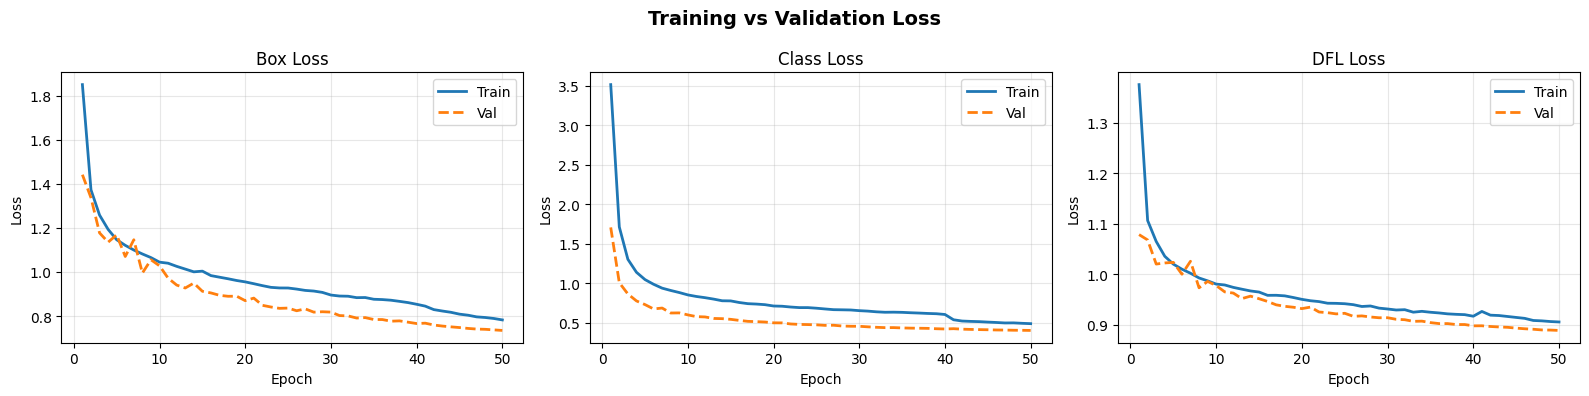

Loss curves saved.


In [14]:
# ── Training & Validation Loss Curves ─────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

RESULTS_CSV = '/content/runs/braille_yolov8n/results.csv'

df = pd.read_csv(RESULTS_CSV)
df.columns = df.columns.str.strip()   # remove any whitespace in headers
epochs = df['epoch']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Training vs Validation Loss', fontsize=14, fontweight='bold')

loss_pairs = [
    ('train/box_loss', 'val/box_loss',   'Box Loss'),
    ('train/cls_loss', 'val/cls_loss',   'Class Loss'),
    ('train/dfl_loss', 'val/dfl_loss',   'DFL Loss'),
]

for ax, (tr_col, val_col, title) in zip(axes, loss_pairs):
    ax.plot(epochs, df[tr_col],  label='Train', linewidth=2)
    ax.plot(epochs, df[val_col], label='Val',   linewidth=2, linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/saved_models/loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Loss curves saved.')

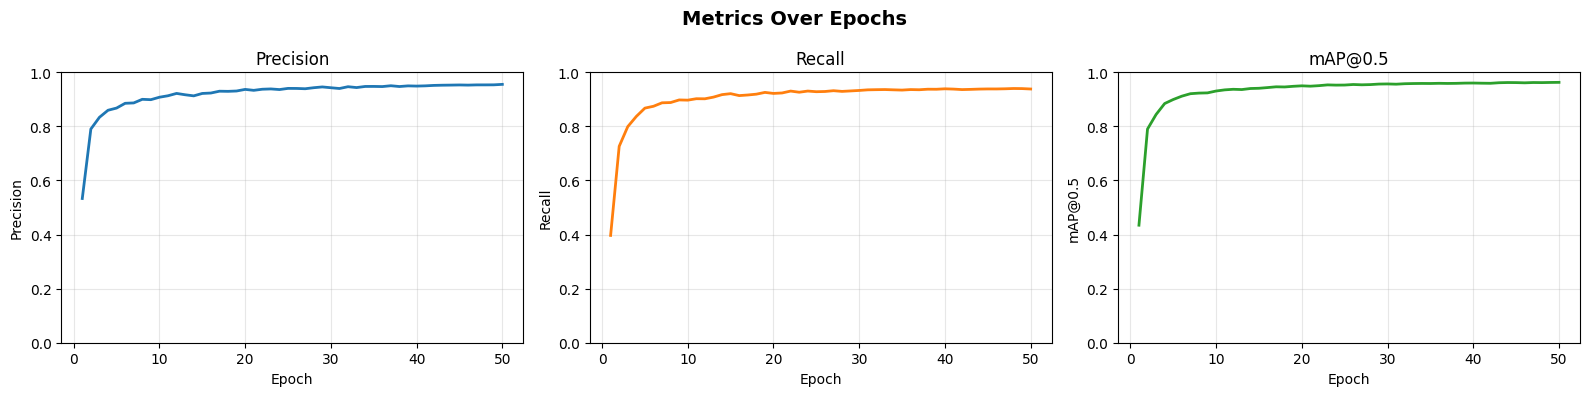

Metric curves saved.


In [15]:
# ── Per-Epoch Precision, Recall & mAP Curves ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Metrics Over Epochs', fontsize=14, fontweight='bold')

metric_cfg = [
    ('metrics/precision(B)', 'Precision',  'tab:blue'),
    ('metrics/recall(B)',    'Recall',     'tab:orange'),
    ('metrics/mAP50(B)',     'mAP@0.5',   'tab:green'),
]

for ax, (col, label, color) in zip(axes, metric_cfg):
    ax.plot(epochs, df[col], color=color, linewidth=2)
    ax.set_title(label)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(label)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/saved_models/metric_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Metric curves saved.')

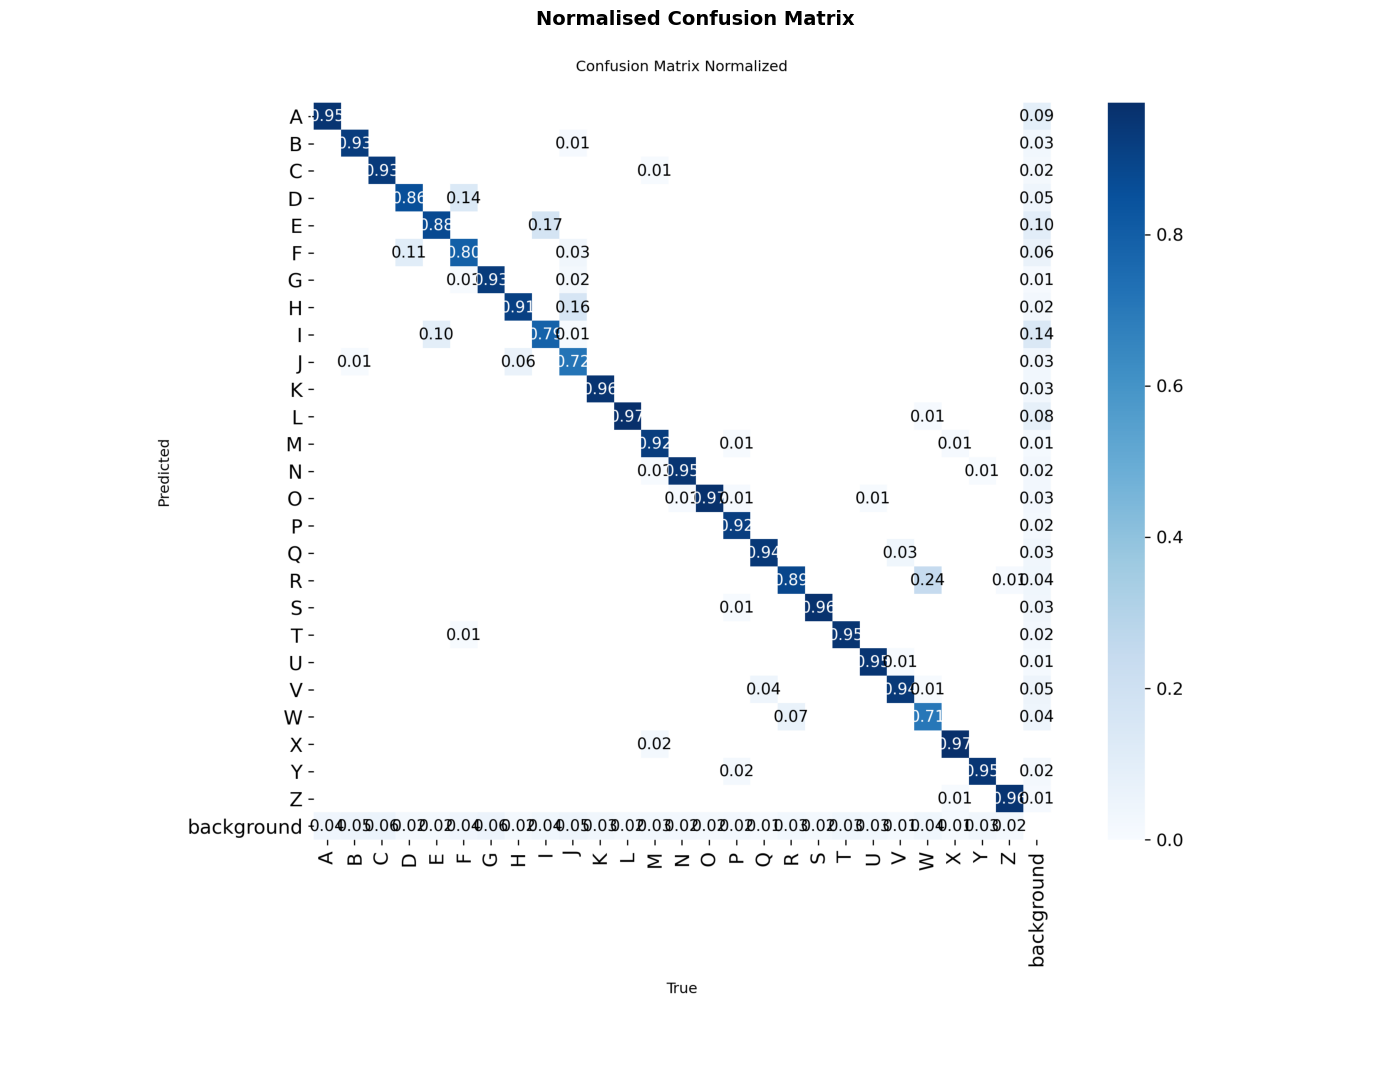

Confusion matrix loaded from: /content/runs/braille_yolov8n/confusion_matrix_normalized.png


In [16]:
# ── Confusion Matrix ────────────────────────────────────────────────────
from PIL import Image
import matplotlib.pyplot as plt

RUN_DIR = '/content/runs/braille_yolov8n'

# Prefer the normalised version for readability
cm_norm_path = os.path.join(RUN_DIR, 'confusion_matrix_normalized.png')
cm_path      = os.path.join(RUN_DIR, 'confusion_matrix.png')

chosen = cm_norm_path if os.path.exists(cm_norm_path) else cm_path

if os.path.exists(chosen):
    img = Image.open(chosen)
    fig, ax = plt.subplots(figsize=(14, 12))
    ax.imshow(img)
    ax.axis('off')
    title = 'Normalised Confusion Matrix' if 'normalized' in chosen else 'Confusion Matrix'
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.savefig('/content/saved_models/confusion_matrix_display.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Confusion matrix loaded from: {chosen}')
else:
    # Generate programmatically from validation results
    print('Pre-saved confusion matrix not found — re-running validation to generate it.')
    best_model_cm = YOLO('/content/saved_models/braille_best.pt')
    best_model_cm.val(data=yaml_path, plots=True)
    val_dir = sorted(
        [d for d in os.scandir('/content/runs/detect') if d.is_dir()],
        key=lambda d: d.stat().st_mtime
    )[-1].path
    cm_img = Image.open(os.path.join(val_dir, 'confusion_matrix_normalized.png'))
    plt.figure(figsize=(14, 12))
    plt.imshow(cm_img)
    plt.axis('off')
    plt.title('Normalised Confusion Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/saved_models/confusion_matrix_display.png', dpi=150, bbox_inches='tight')
    plt.show()

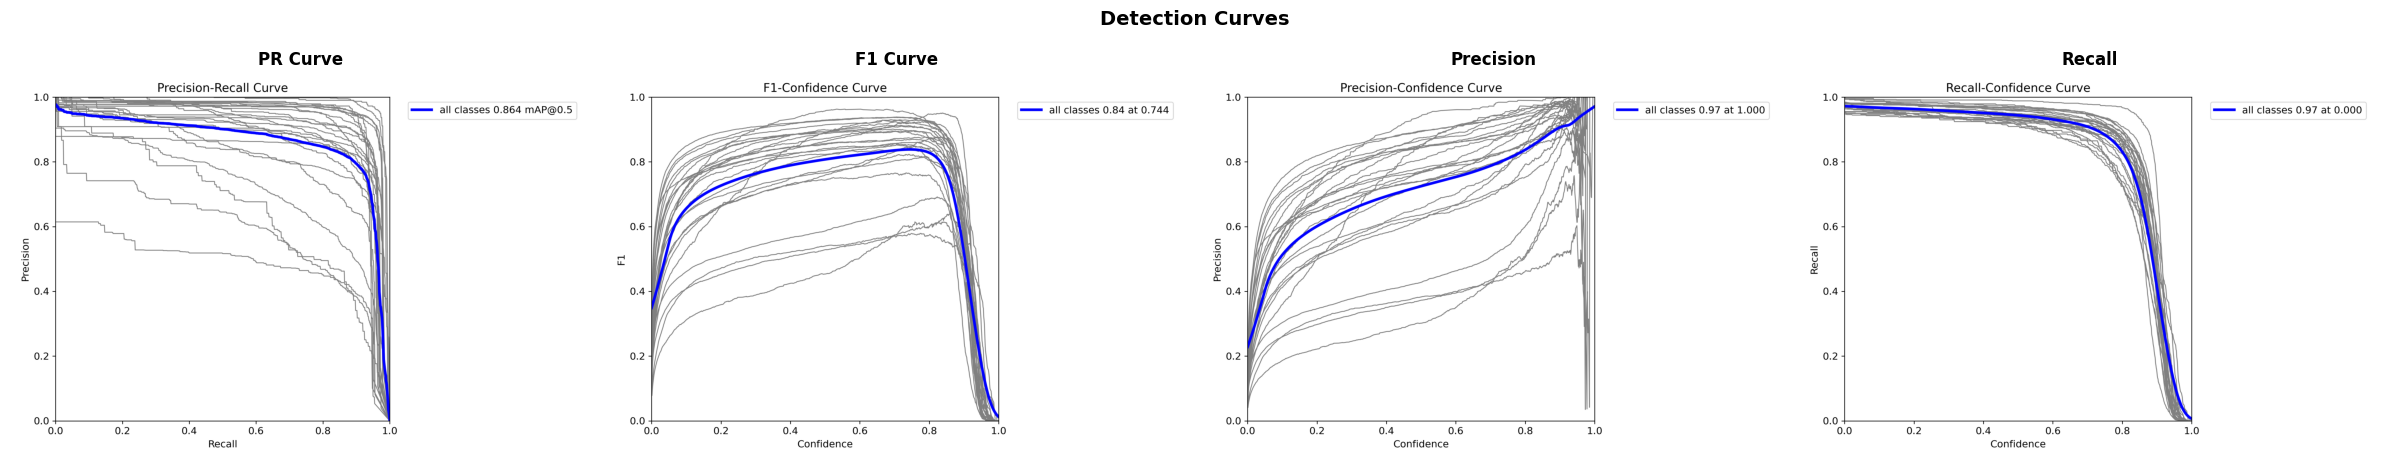

Showing 4 curve(s): ['PR Curve', 'F1 Curve', 'Precision', 'Recall']


In [17]:
# ── PR Curve & F1 Curve ─────────────────────────────────────────────────
from PIL import Image
import matplotlib.pyplot as plt

curve_files = {
    'PR Curve':  'BoxPR_curve.png',
    'F1 Curve':  'BoxF1_curve.png',
    'Precision': 'BoxP_curve.png',
    'Recall':    'BoxR_curve.png',
}

available = {title: os.path.join(RUN_DIR, fname)
             for title, fname in curve_files.items()
             if os.path.exists(os.path.join(RUN_DIR, fname))}

if available:
    n = len(available)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1: axes = [axes]
    for ax, (title, path) in zip(axes, available.items()):
        ax.imshow(Image.open(path))
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.axis('off')
    plt.suptitle('Detection Curves', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/saved_models/pr_f1_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Showing {n} curve(s): {list(available.keys())}')
else:
    print('No curve images found in run directory — run validation with plots=True first.')

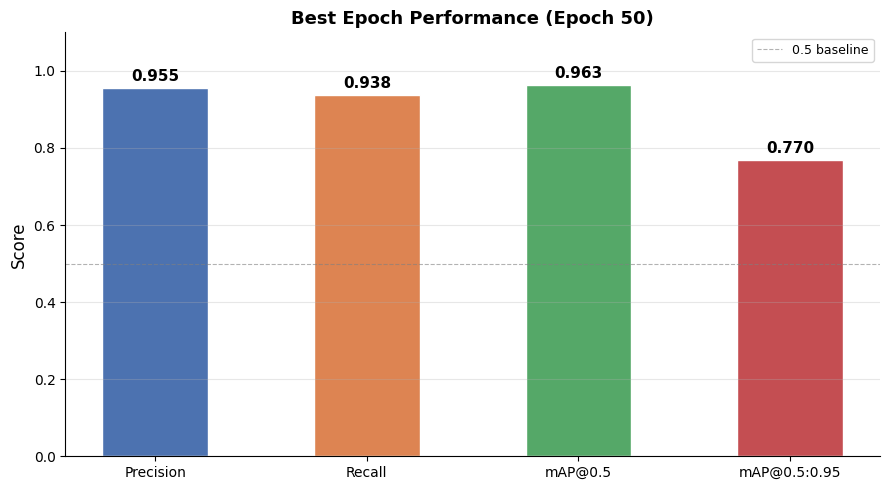

Best epoch: 50
  Precision       : 0.9555
  Recall          : 0.9384
  mAP@0.5         : 0.9629
  mAP@0.5:0.95    : 0.7698


In [18]:
# ── Summary Bar Chart: Final Metrics ────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

# Pull the best epoch values (highest mAP50 row)
best_row = df.loc[df['metrics/mAP50(B)'].idxmax()]

metric_names  = ['Precision', 'Recall', 'mAP@0.5', 'mAP@0.5:0.95']
metric_cols   = ['metrics/precision(B)', 'metrics/recall(B)',
                 'metrics/mAP50(B)',       'metrics/mAP50-95(B)']
metric_values = [best_row[c] for c in metric_cols]
colors        = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(metric_names, metric_values, color=colors, width=0.5, edgecolor='white')

# Value labels on top of bars
for bar, val in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{val:.3f}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Best Epoch Performance (Epoch {int(best_row["epoch"])})',
             fontsize=13, fontweight='bold')
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='0.5 baseline')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/saved_models/summary_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best epoch: {int(best_row["epoch"])}')
for name, val in zip(metric_names, metric_values):
    print(f'  {name:<16}: {val:.4f}')

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 73 layers, 3,010,718 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1137.9±743.1 MB/s, size: 27.0 KB)
val: Scanning /content/merged_dataset/labels/valid.cache... 1608 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1608/1608 613.1Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 450, len(boxes) = 30276. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 101/101 9.5it/s 10.6s
                   all       1608      30276      0.955      0.939      0.963      0.771
Speed: 0.6ms preprocess, 1.0ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /cont

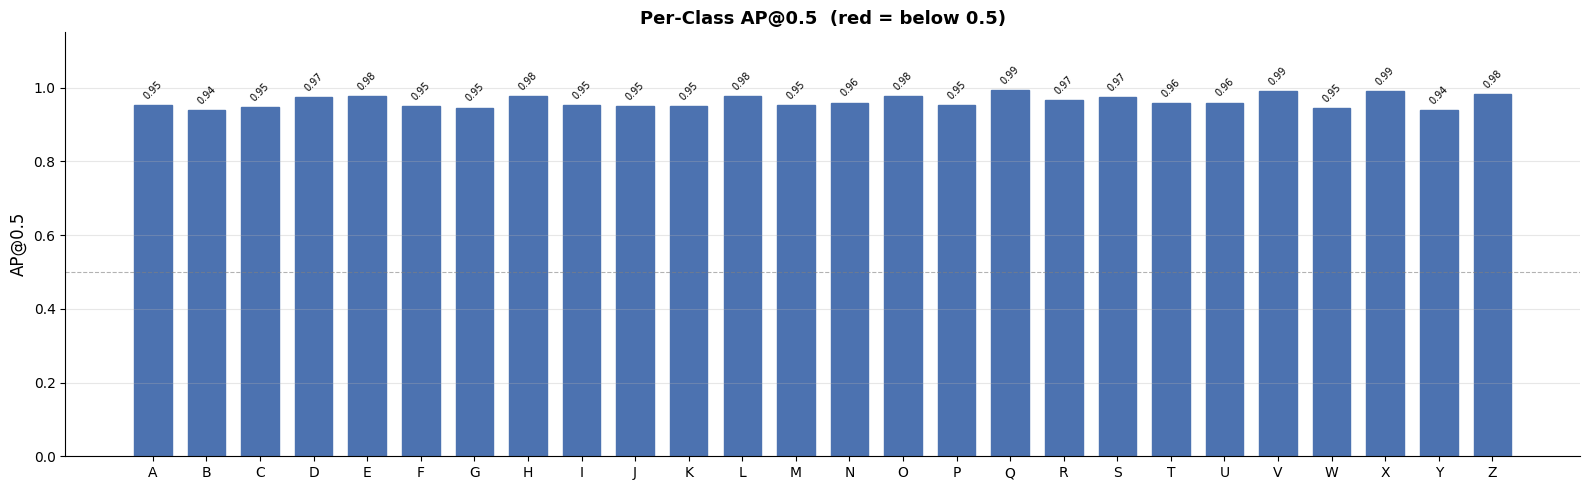

Per-class AP@0.5 saved.


In [19]:
# ── Per-Class Precision & Recall Bar Chart ──────────────────────────────
# Requires running val() with save_json=True or using metrics.box.ap_class_index
from ultralytics import YOLO
import numpy as np
import matplotlib.pyplot as plt

STANDARD_CLASSES = [chr(i) for i in range(ord('A'), ord('Z')+1)]

best_model_eval = YOLO('/content/saved_models/braille_best.pt')
val_metrics = best_model_eval.val(data=yaml_path, verbose=False)

ap_per_class  = val_metrics.box.ap50           # AP@0.5 per class, shape (num_classes,)
class_indices = val_metrics.box.ap_class_index  # which class indices are present

class_labels = [STANDARD_CLASSES[i] if i < len(STANDARD_CLASSES) else str(i)
                for i in class_indices]

x = np.arange(len(class_labels))

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(x, ap_per_class, color='steelblue', edgecolor='white', width=0.7)

# Colour bars below 0.5 in red to highlight weak classes
for bar, val in zip(bars, ap_per_class):
    bar.set_color('#C44E52' if val < 0.5 else '#4C72B0')
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{val:.2f}',
            ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xticks(x)
ax.set_xticklabels(class_labels, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('AP@0.5', fontsize=12)
ax.set_title('Per-Class AP@0.5  (red = below 0.5)', fontsize=13, fontweight='bold')
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/saved_models/per_class_ap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Per-class AP@0.5 saved.')

Testing on: /content/merged_dataset/images/test/test_001432.jpg

Detected 27 characters

Predicted Text:
----------------------------------------
DLOTEVZNSFHLETR
FSSEOQLDSHQE
----------------------------------------


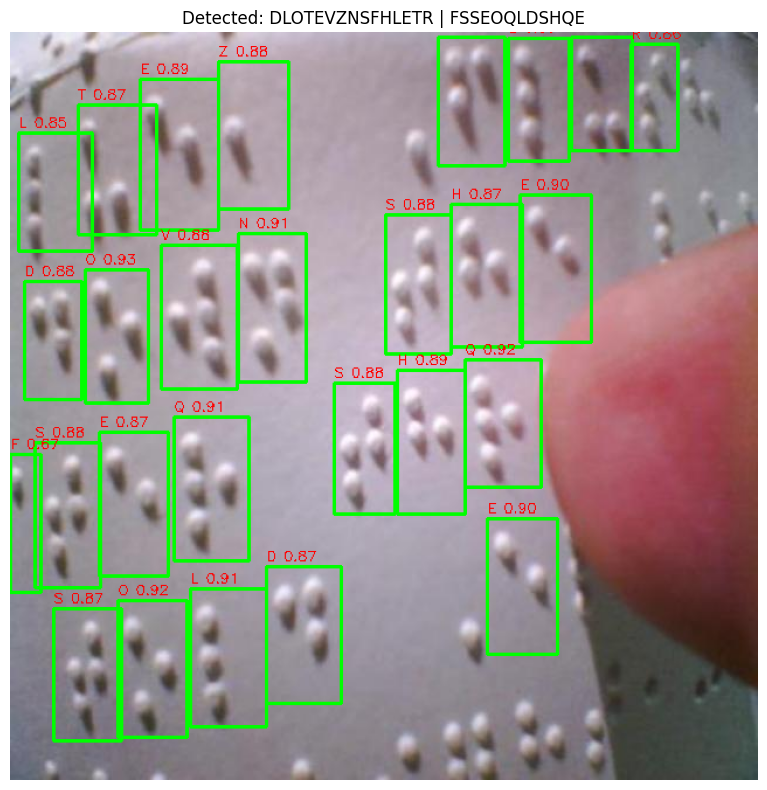

Visualization saved!


In [20]:
# Cell - Braille to Text Pipeline (uses real image from test set)

import glob
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

STANDARD_CLASSES = [chr(i) for i in range(ord('A'), ord('Z')+1)]

# Load best model
best_model = YOLO("/content/saved_models/braille_best.pt")

# Automatically pick a real image from our test set
test_images = glob.glob("/content/merged_dataset/images/test/*")
test_image  = random.choice(test_images)
print(f"Testing on: {test_image}")

#  Full pipeline
def braille_to_text(image_path, model, conf=0.4):
    results = model(image_path, conf=conf, verbose=False)[0]
    boxes   = results.boxes

    if boxes is None or len(boxes) == 0:
        return "", []

    # Extract detections
    detections = []
    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        cls_id   = int(box.cls[0])
        cls_name = STANDARD_CLASSES[cls_id]
        conf_val = float(box.conf[0])
        detections.append({
            'char': cls_name,
            'x'   : (x1 + x2) / 2,
            'y'   : (y1 + y2) / 2,
            'w'   : x2 - x1,
            'h'   : y2 - y1,
            'x1'  : x1, 'y1': y1,
            'x2'  : x2, 'y2': y2,
            'conf': conf_val
        })

    if not detections:
        return "", []

    # Group into rows using y-coordinate
    avg_height    = np.mean([d['h'] for d in detections])
    row_threshold = avg_height * 0.6

    detections.sort(key=lambda d: (d['y'], d['x']))

    rows        = []
    current_row = [detections[0]]

    for det in detections[1:]:
        if abs(det['y'] - current_row[-1]['y']) < row_threshold:
            current_row.append(det)
        else:
            rows.append(sorted(current_row, key=lambda d: d['x']))
            current_row = [det]
    rows.append(sorted(current_row, key=lambda d: d['x']))

    # Group into words using x-gap
    avg_width         = np.mean([d['w'] for d in detections])
    word_gap_threshold = avg_width * 1.5

    full_text = []
    for row in rows:
        words_in_row = []
        current_word = [row[0]]
        for i in range(1, len(row)):
            gap = row[i]['x1'] - row[i-1]['x2']
            if gap > word_gap_threshold:
                words_in_row.append(''.join(c['char'] for c in current_word))
                current_word = [row[i]]
            else:
                current_word.append(row[i])
        words_in_row.append(''.join(c['char'] for c in current_word))
        full_text.append(' '.join(words_in_row))

    return '\n'.join(full_text), detections


# Run prediction
predicted_text, detections = braille_to_text(test_image, best_model)

print(f"\nDetected {len(detections)} characters")
print(f"\nPredicted Text:")
print("-" * 40)
print(predicted_text if predicted_text else "(no characters detected)")
print("-" * 40)

#  Visualize results
img = cv2.imread(test_image)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

for det in detections:
    x1, y1, x2, y2 = int(det['x1']), int(det['y1']), \
                      int(det['x2']), int(det['y2'])
    # Draw box
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    # Draw label
    label = f"{det['char']} {det['conf']:.2f}"
    cv2.putText(img, label, (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)

plt.figure(figsize=(14, 8))
plt.imshow(img)
plt.title(f"Detected: {predicted_text.replace(chr(10), ' | ')}", fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.savefig("/content/saved_models/sample_prediction.png", dpi=150)
plt.show()
print("Visualization saved!")

In [21]:
# ── CER: Batch Evaluation Across the Full Test Set ──────────────────────────
# Ground truth is reconstructed from YOLO label files (same row-grouping logic
# as the pipeline), so no separate text annotation is needed.

import glob, os, cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

STANDARD_CLASSES = [chr(i) for i in range(ord('A'), ord('Z')+1)]
TEST_IMG_DIR = '/content/merged_dataset/images/test'
TEST_LBL_DIR = '/content/merged_dataset/labels/test'

# ── Levenshtein / CER ────────────────────────────────────────────────────────
def compute_cer(reference, hypothesis):
    ref = reference.replace(' ', '').replace('\n', '').upper()
    hyp = hypothesis.replace(' ', '').replace('\n', '').upper()
    if not ref:
        return 0.0 if not hyp else 1.0
    m, n = len(ref), len(hyp)
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(m+1): dp[i][0] = i
    for j in range(n+1): dp[0][j] = j
    for i in range(1, m+1):
        for j in range(1, n+1):
            cost = 0 if ref[i-1] == hyp[j-1] else 1
            dp[i][j] = min(dp[i-1][j]+1, dp[i][j-1]+1, dp[i-1][j-1]+cost)
    return dp[m][n] / len(ref)

# ── Reconstruct ground-truth text from a YOLO label file ────────────────────
def gt_from_label(label_path, img_w, img_h):
    boxes = []
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            x1 = (cx - bw/2) * img_w
            y1 = (cy - bh/2) * img_h
            x2 = (cx + bw/2) * img_w
            y2 = (cy + bh/2) * img_h
            boxes.append({'cls': cls_id, 'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2,
                          'cx': cx*img_w, 'cy': cy*img_h, 'h': bh*img_h, 'w': bw*img_w})
    if not boxes:
        return ''
    avg_h = np.mean([b['h'] for b in boxes])
    row_thresh = avg_h * 0.6
    boxes.sort(key=lambda b: (b['cy'], b['cx']))
    rows, cur = [], [boxes[0]]
    for b in boxes[1:]:
        if abs(b['cy'] - cur[-1]['cy']) < row_thresh:
            cur.append(b)
        else:
            rows.append(sorted(cur, key=lambda b: b['cx']))
            cur = [b]
    rows.append(sorted(cur, key=lambda b: b['cx']))
    avg_w = np.mean([b['w'] for b in boxes])
    word_gap = avg_w * 1.5
    lines = []
    for row in rows:
        words, word = [], [row[0]]
        for i in range(1, len(row)):
            if row[i]['x1'] - row[i-1]['x2'] > word_gap:
                words.append(''.join(STANDARD_CLASSES[b['cls']] for b in word
                                     if b['cls'] < len(STANDARD_CLASSES)))
                word = [row[i]]
            else:
                word.append(row[i])
        words.append(''.join(STANDARD_CLASSES[b['cls']] for b in word
                              if b['cls'] < len(STANDARD_CLASSES)))
        lines.append(' '.join(words))
    return '\n'.join(lines)

# ── Run batch evaluation ──────────────────────────────────────────────────────
model_cer = YOLO('/content/saved_models/braille_best.pt')

test_images = sorted(glob.glob(f'{TEST_IMG_DIR}/*'))
print(f'Evaluating CER on {len(test_images)} test images...')

cer_scores, results_log = [], []
for img_path in test_images:
    lbl_path = os.path.join(TEST_LBL_DIR, Path(img_path).stem + '.txt')
    if not os.path.exists(lbl_path):
        continue
    img = cv2.imread(img_path)
    if img is None:
        continue
    h, w = img.shape[:2]
    gt_text   = gt_from_label(lbl_path, w, h)
    pred_text, _ = braille_to_text(img_path, model_cer)
    if not gt_text.strip():
        continue
    cer = compute_cer(gt_text, pred_text)
    cer_scores.append(cer)
    results_log.append({'file': Path(img_path).name, 'gt': gt_text, 'pred': pred_text, 'cer': cer})

print(f'\nEvaluated {len(cer_scores)} images with ground truth labels.')
if cer_scores:
    print(f'  Mean CER : {np.mean(cer_scores):.2%}')
    print(f'  Median   : {np.median(cer_scores):.2%}')
    print(f'  Best     : {np.min(cer_scores):.2%}')
    print(f'  Worst    : {np.max(cer_scores):.2%}')
    pct_pass = np.mean([c <= 0.10 for c in cer_scores]) * 100
    print(f'  CER ≤ 10%: {pct_pass:.1f}% of images (target)')


Evaluating CER on 1650 test images...

Evaluated 1650 images with ground truth labels.
  Mean CER : 17.70%
  Median   : 8.33%
  Best     : 0.00%
  Worst    : 200.00%
  CER ≤ 10%: 55.2% of images (target)


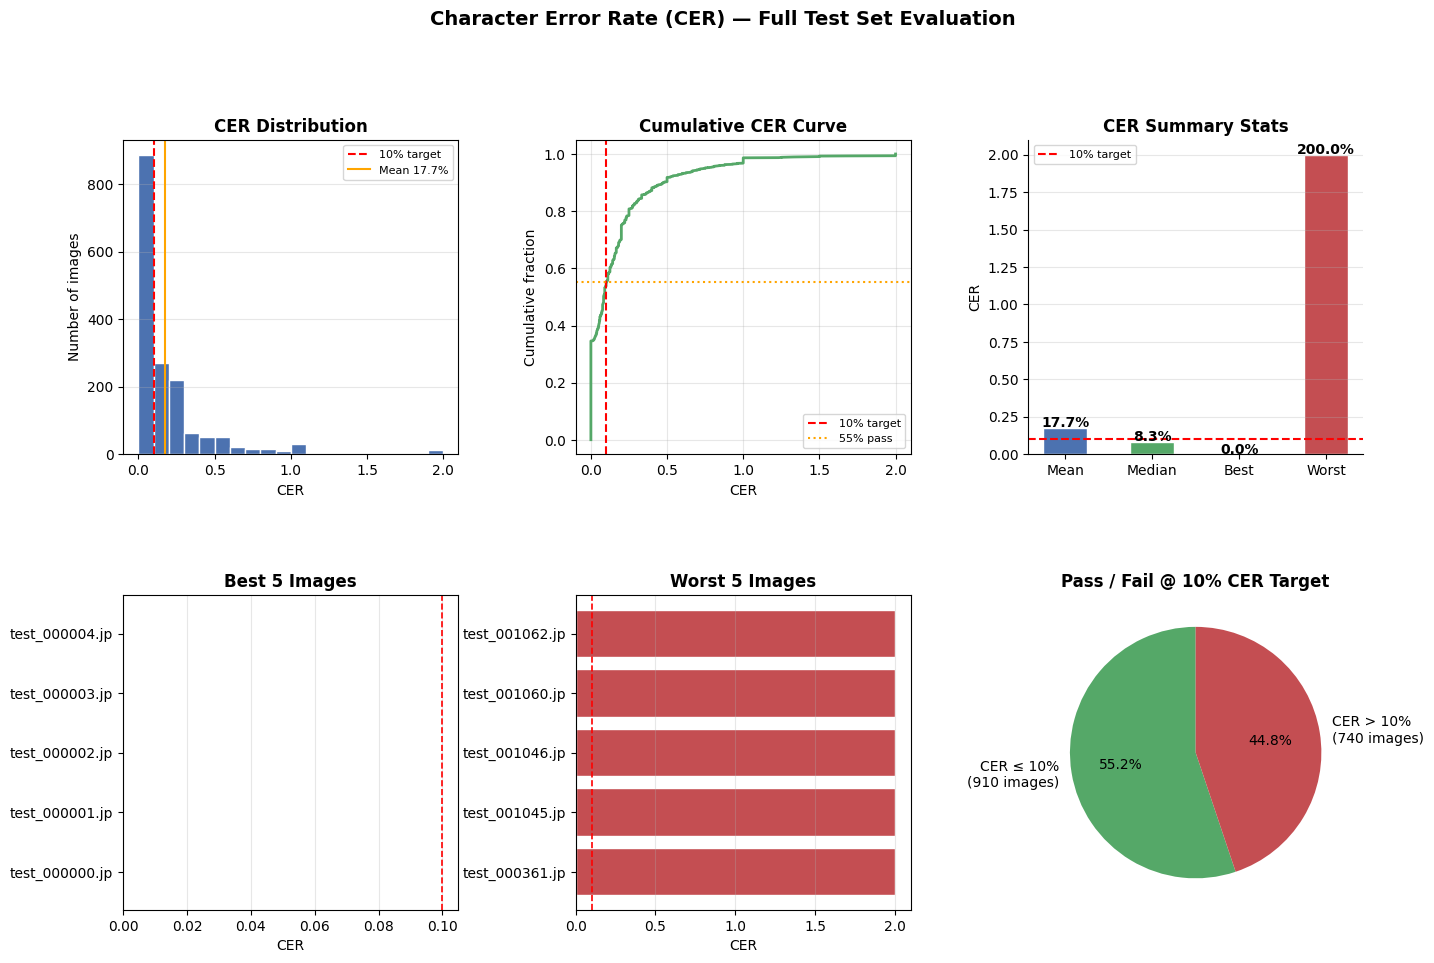

CER visualisations saved.


In [22]:
# ── CER Visualisations ───────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

if not cer_scores:
    print("No CER scores to plot — check that test label files exist.")
else:
    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    # ── 1. Histogram ─────────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.hist(cer_scores, bins=20, color='#4C72B0', edgecolor='white')
    ax1.axvline(0.10, color='red', linestyle='--', linewidth=1.5, label='10% target')
    ax1.axvline(np.mean(cer_scores), color='orange', linestyle='-', linewidth=1.5,
                label=f'Mean {np.mean(cer_scores):.1%}')
    ax1.set_xlabel('CER'); ax1.set_ylabel('Number of images')
    ax1.set_title('CER Distribution', fontweight='bold')
    ax1.legend(fontsize=8); ax1.grid(axis='y', alpha=0.3)

    # ── 2. Cumulative CER curve ───────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    sorted_cer = np.sort(cer_scores)
    cum = np.arange(1, len(sorted_cer)+1) / len(sorted_cer)
    ax2.plot(sorted_cer, cum, color='#55A868', linewidth=2)
    ax2.axvline(0.10, color='red', linestyle='--', linewidth=1.5, label='10% target')
    ax2.axhline(np.mean([c <= 0.10 for c in cer_scores]), color='orange',
                linestyle=':', linewidth=1.5,
                label=f'{np.mean([c<=0.10 for c in cer_scores]):.0%} pass')
    ax2.set_xlabel('CER'); ax2.set_ylabel('Cumulative fraction')
    ax2.set_title('Cumulative CER Curve', fontweight='bold')
    ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

    # ── 3. Summary bar: mean / median / best / worst ─────────────────────────
    ax3 = fig.add_subplot(gs[0, 2])
    labels = ['Mean', 'Median', 'Best', 'Worst']
    vals   = [np.mean(cer_scores), np.median(cer_scores),
              np.min(cer_scores),  np.max(cer_scores)]
    colors = ['#4C72B0', '#55A868', '#2ca02c', '#C44E52']
    bars = ax3.bar(labels, vals, color=colors, edgecolor='white', width=0.5)
    ax3.axhline(0.10, color='red', linestyle='--', linewidth=1.5, label='10% target')
    for bar, v in zip(bars, vals):
        ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{v:.1%}', ha='center', fontsize=10, fontweight='bold')
    ax3.set_ylabel('CER'); ax3.set_title('CER Summary Stats', fontweight='bold')
    ax3.legend(fontsize=8); ax3.grid(axis='y', alpha=0.3)
    ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

    # ── 4. Best 5 images ──────────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 0])
    top5    = sorted(results_log, key=lambda r: r['cer'])[:5]
    names5  = [r['file'][:14] for r in top5]
    cers5   = [r['cer']      for r in top5]
    ax4.barh(names5, cers5, color='#2ca02c', edgecolor='white')
    ax4.axvline(0.10, color='red', linestyle='--', linewidth=1.2)
    ax4.set_xlabel('CER'); ax4.set_title('Best 5 Images', fontweight='bold')
    ax4.grid(axis='x', alpha=0.3)

    # ── 5. Worst 5 images ─────────────────────────────────────────────────────
    ax5 = fig.add_subplot(gs[1, 1])
    bot5   = sorted(results_log, key=lambda r: r['cer'], reverse=True)[:5]
    names5b = [r['file'][:14] for r in bot5]
    cers5b  = [r['cer']       for r in bot5]
    ax5.barh(names5b, cers5b, color='#C44E52', edgecolor='white')
    ax5.axvline(0.10, color='red', linestyle='--', linewidth=1.2)
    ax5.set_xlabel('CER'); ax5.set_title('Worst 5 Images', fontweight='bold')
    ax5.grid(axis='x', alpha=0.3)

    # ── 6. Pass / Fail pie ────────────────────────────────────────────────────
    ax6 = fig.add_subplot(gs[1, 2])
    n_pass = sum(c <= 0.10 for c in cer_scores)
    n_fail = len(cer_scores) - n_pass
    ax6.pie([n_pass, n_fail],
            labels=[f'CER ≤ 10%\n({n_pass} images)', f'CER > 10%\n({n_fail} images)'],
            colors=['#55A868', '#C44E52'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 10})
    ax6.set_title('Pass / Fail @ 10% CER Target', fontweight='bold')

    fig.suptitle('Character Error Rate (CER) — Full Test Set Evaluation',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.savefig('/content/saved_models/cer_visualisations.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('CER visualisations saved.')
